# Seminar 2

In [1]:
import numpy as np
from scipy import stats
from scipy.stats import norm
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(font_scale=2)

# A Minute of Theory

## Notation

$\theta_0$ — the true parameters, $\hat{\theta}$ — the MLE estimate.

Expand the log-likelihood using the Taylor formula around $(\hat{\theta})$:

$$
\log L(\theta) \approx 
\log L(\hat{\theta}) 
+ S(\hat{\theta}) (\theta - \hat{\theta}) 
- \frac{1}{2} I(\hat{\theta}) (\theta - \hat{\theta})^2
$$

By the definition of $\hat{\theta}$:

$$
S(\hat\theta) = \frac{d}{d\theta} \log L(\theta)\big|_{\hat\theta} = 0
$$

## Fisher Information

Correct definition:

$$
I(\theta) = \mathrm{Var}_\theta\!\left(\frac{d}{d\theta}\log p(X|\theta)\right)
= E_\theta\!\left[\left(\frac{d}{d\theta}\log p(X|\theta)\right)^2\right]
$$

For $n$ i.i.d. observations:

$$
I_{n}(\theta) = \sum_{x_i} 
E_\theta\!\left[
\left( \frac{d}{d\theta} \log p(x_i | \theta) \right)^2
\right]
= n\, E_\theta\!\left[
\left( \frac{d}{d\theta} \log p(X | \theta) \right)^2
\right]
$$

Equivalent second-derivative form:

$$
I_{n}(\theta) 
= - \sum_{x_i} E_\theta\!\left[
\frac{d^2}{d\theta^2} \log p(x_i | \theta)
\right]
= - n\, E_\theta\!\left[
\frac{d^2}{d\theta^2} \log p(X | \theta)
\right]
$$

Observed Fisher information:

$$
I_{\text{obs}}(\theta) 
= - \frac{d^2}{d\theta^2} \log p(x | \theta)
= - \sum_{x_i} \frac{d^2}{d\theta^2} \log p(x_i | \theta)
$$

Physical meaning: how much information is contained in a single observation $x_i$.
(We will explore Fisher information more closely in the problem at the end of the seminar — it is a very powerful tool despite its simplicity.)

## Wald’s Theorem

$$
\sqrt{n}(\hat{\theta} - \theta_0)
\;\xrightarrow{d}\;
\mathcal{N}\!\left(0, \frac{1}{I(\theta_0)}\right)
$$

This result is obtained by expanding the log-likelihood into a Taylor series up to 
$\frac{d^3 L}{d\theta^3}$ and applying the law of large numbers when summing likelihood contributions over the observations $x_i$.

Note that $I(\theta)$ may refer to either the observed or the expected Fisher information.
Classical textbooks usually assume the expected Fisher information, but some papers argue that the observed Fisher information yields better estimates [1].

[1] https://academic.oup.com/biomet/article-abstract/65/3/457/233667?redirectedFrom=fulltext

# 1. Wald’s Method for Constructing Confidence Intervals

## Wald Interval Estimation for the Bernoulli Distribution

The correctness of applying Wald’s theorem for confidence interval estimation depends strongly on how quadratic (i.e., how close to normal) the log-likelihood is in a neighborhood of $\theta_0$.

Using the Bernoulli distribution as an example, we will examine how regular the likelihood is under different sample sizes and parameterizations.

In [2]:
x = 8
n = 10
theta_hat = x / n

In [3]:
# real likehood and scoring functions
log_likelihood = lambda x, n, theta, theta_hat: x * np.log(theta) + (n - x) * np.log(1 - theta)
score_function = lambda x, n, theta, theta_hat: (x / theta - (n - x) / (1 - theta))

In [4]:
# observed fischer information
I_theta = lambda x, n, theta: x / theta**2 + (n - x) / (1 - theta)**2

In [5]:
# quadratic and linear model of likelhood and scoring
log_likelihood_quadratic = lambda x, n, theta, theta_hat: -I_theta(x, n, theta_hat) * (theta - theta_hat)**2 / 2
score_function_linear = lambda x, n, theta, theta_hat: -I_theta(x, n, theta_hat) * (theta - theta_hat)

In [6]:
EPS = 0.01
theta = np.linspace(0.1, 1 - EPS, 100)

### pay attention

When plotting the score function, instead of drawing $\theta$ vs. $S(\theta)$, we will plot the following:

$$\text{X-axis: } (\theta - \hat\theta)\,\sqrt{I(\hat\theta)}$$
$$\text{Y-axis: } \frac{S(\theta)}{\sqrt{I(\hat\theta)}}$$

Advantages: dimensionless quantities and independence from scaling.

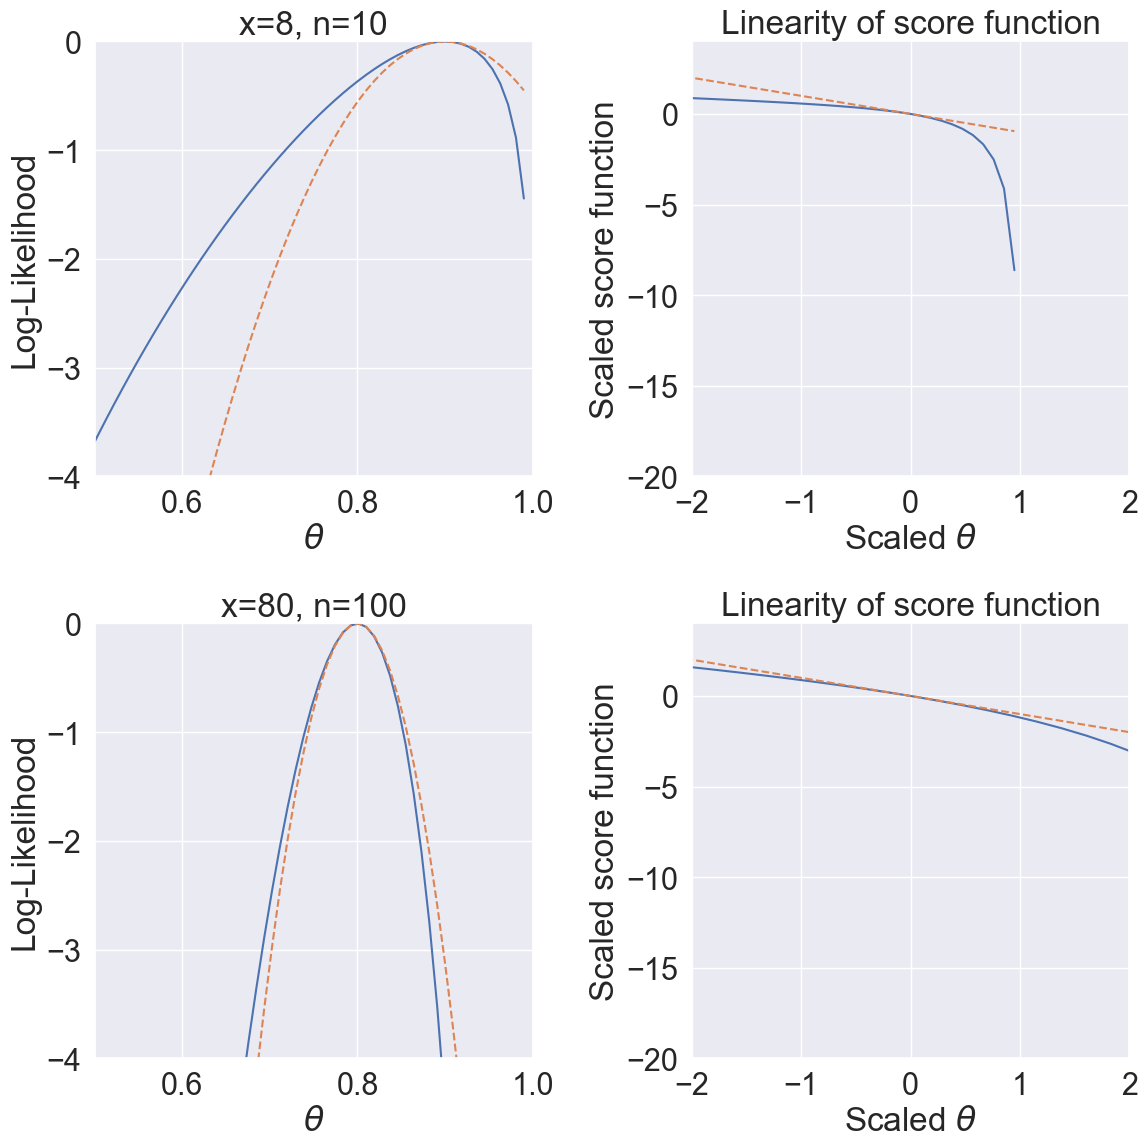

In [7]:
# plot both 
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

x = 9
n = 10
theta_hat = x / n


# plot log likelihood quadratic and true on theta n = 10
axes[0][0].plot(theta, log_likelihood(x, n, theta, theta_hat) - log_likelihood(x, n, theta, theta_hat).max(), label="True likelihood")
axes[0][0].plot(theta, log_likelihood_quadratic(x, n, theta, theta_hat), linestyle="--", label="Quadratic likelihood")
axes[0][0].set_xlim(0.5, 1)
axes[0][0].set_ylim(-4., 0.)
axes[0][0].set_title("x=8, n=10")
axes[0][0].set_ylabel("Log-Likelihood")
axes[0][0].set_xlabel(r"$\theta$")


# plot score n = 10
axes[0][1].plot(
    (theta - theta_hat) * np.sqrt(I_theta(x, n, theta_hat)), 
    score_function(x, n, theta, theta_hat) / np.sqrt(I_theta(x, n, theta_hat)), 
    label="True score function"
)
axes[0][1].plot(
    (theta - theta_hat) * np.sqrt(I_theta(x, n, theta_hat)), 
    score_function_linear(x, n, theta, theta_hat) / np.sqrt(I_theta(x, n, theta_hat)), 
    linestyle="--", label="Linear score function"
)
axes[0][1].set_xlim(-2, 2)
axes[0][1].set_title("Linearity of score function")
axes[0][1].set_ylabel("Scaled score function")
axes[0][1].set_xlabel(r"Scaled $\theta$")
axes[0][1].set_ylim(-20., 4.)



x = 80
n = 100
theta_hat = x / n

# ll n = 100
axes[1][0].plot(theta, log_likelihood(x, n, theta, theta_hat) - log_likelihood(x, n, theta, theta_hat).max(), label="True likelihood")
axes[1][0].plot(theta, log_likelihood_quadratic(x, n, theta, theta_hat), linestyle="--", label="Quadratic likelihood")
axes[1][0].set_xlim(0.5, 1)
axes[1][0].set_ylim(-4., 0.)
axes[1][0].set_title("x=80, n=100")
axes[1][0].set_ylabel("Log-Likelihood")
axes[1][0].set_xlabel(r"$\theta$")

# plot score n = 100 
axes[1][1].plot(
    (theta - theta_hat) * np.sqrt(I_theta(x, n, theta_hat)), 
    score_function(x, n, theta, theta_hat) / np.sqrt(I_theta(x, n, theta_hat)), 
    label="True score function"
)
axes[1][1].plot(
    (theta - theta_hat) * np.sqrt(I_theta(x, n, theta_hat)), 
    score_function_linear(x, n, theta, theta_hat) / np.sqrt(I_theta(x, n, theta_hat)), 
    linestyle="--", label="Linear score function"
)
axes[1][1].set_xlim(-2, 2)
axes[1][1].set_title("Linearity of score function")
axes[1][1].set_ylabel("Scaled score function")
axes[1][1].set_xlabel(r"Scaled $\theta$")
axes[1][1].set_ylim(-20., 4.)

plt.tight_layout()
plt.show()

## Let’s Try Changing the Parameterization

$$\psi = \log \frac{\theta}{1 - \theta}$$

### How Does the Fisher Information Change?

We apply the chain rule for differentiation and use the fact that  
$E_{p(x|\theta)}\frac{d}{d\theta} \log p(x|\theta) = 0$:

$$
I(\psi)
= -E_{p(x|\psi)} \frac{d^2}{d\psi^2} \log p(x \mid \psi(\theta))
= -E_{p(x|\theta)}\left(
\frac{d^2}{d\theta^2}\log p(x \mid \psi(\theta))\left(\frac{d\theta}{d\psi}\right)^2
+ \frac{d}{d\theta}\log p(x \mid \psi(\theta)) \frac{d^2\theta}{d\psi^2}
\right)
= -E_{p(x|\theta)} \frac{d^2}{d\theta^2}\log p(x \mid \psi(\theta))\left(\frac{d\theta}{d\psi}\right)^2
$$

$$
I(\psi) = I(\theta)\left(\frac{d\theta}{d\psi}\right)^2
$$

#### Note that this is exactly the main delta‑method formula relating variances under reparameterization!

### How Does the Score Change?

$$
S(\psi(\theta))
= \frac{d}{d\psi}\log p(x \mid \psi(\theta))
= S(\theta)\frac{d\theta}{d\psi}
$$

In [8]:
from scipy.special import expit
psi = lambda theta: np.log(theta / (1 - theta))
psi_grad = lambda theta: theta * (1 - theta)


I_psi = lambda x, n, theta_hat: I_theta(x, n, theta_hat) * psi_grad(theta_hat)**2

In [9]:
# quadratic and linear model of likelhood and scoring
log_likelihood_quadratic_psi = lambda x, n, theta, theta_hat: -I_psi(x, n, theta_hat) * (psi(theta) - psi(theta_hat))**2 / 2
score_function_linear_psi = lambda x, n, theta, theta_hat: -I_psi(x, n, theta_hat) * (psi(theta) - psi(theta_hat))

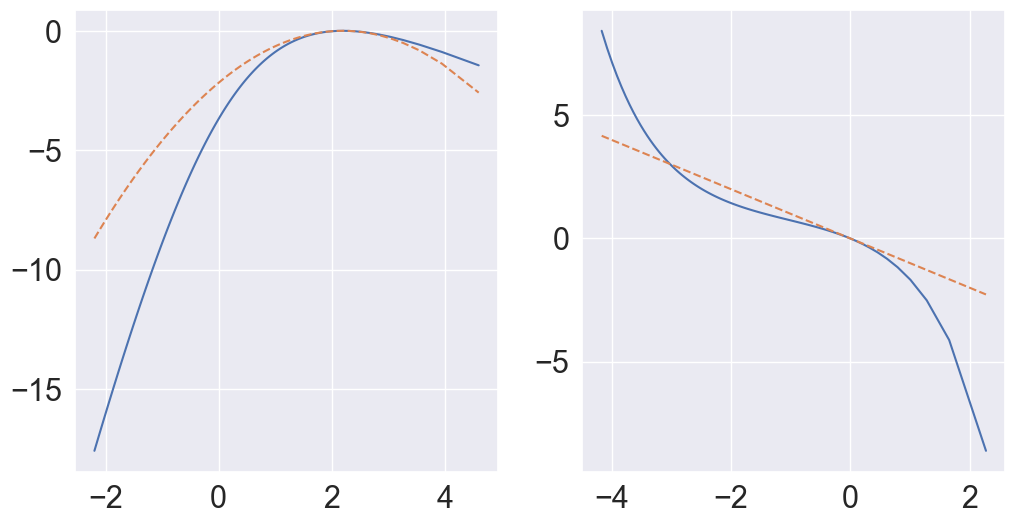

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# plot log likelihood quadratic and true on psi
x = 9
n = 10
theta_hat = x / n
# plot log likelihood quadratic and true on theta n = 10
axes[0].plot(
    psi(theta), 
    log_likelihood(x, n, theta, theta_hat) - log_likelihood(x, n, theta, theta_hat).max(), 
    label="True likelihood")
axes[0].plot(psi(theta), log_likelihood_quadratic_psi(x, n, theta, theta_hat), linestyle="--")

# plot score n = 10

# plot score n = 100 
axes[1].plot(
    (psi(theta) - psi(theta_hat)) * np.sqrt(I_psi(x, n, theta_hat)), 
    score_function(x, n, theta, theta_hat) * psi_grad(theta_hat) / np.sqrt(I_psi(x, n, theta_hat)), 
    label="True score function"
)
axes[1].plot(
    (psi(theta) - psi(theta_hat)) * np.sqrt(I_psi(x, n, theta_hat)), 
    score_function_linear_psi(x, n, theta, theta_hat) / np.sqrt(I_psi(x, n, theta_hat)), 
    linestyle="--", label="Linear score function"
)

plt.show()

## Let’s Compute the Coverage

In [17]:
import scipy.stats as st
q = st.norm.ppf(.95) # 90% интервал
true_p = 0.95
psi_inverse = lambda psi: expit(psi)

In [18]:
coverage_theta = []
coverage_psi = []

for i in range(1000):
    x = np.random.binomial(n=1, p=true_p, size=10)
    p = np.clip(x.mean(), 1e-5, 1 - 1e-5)
    p_psi = psi(p)
    
    std_theta = 1 / np.sqrt(I_theta(x.sum(), len(x), p))
    std_psi = 1 / np.sqrt(I_psi(x.sum(), len(x), p))
    
    if p - q * std_theta < true_p < p + q * std_theta:
        coverage_theta.append(1)
    else:
        coverage_theta.append(0)
    
    if psi_inverse(p_psi - q * std_psi) < true_p < psi_inverse(p_psi + q * std_psi):
        coverage_psi.append(1)
    else:
        coverage_psi.append(0)

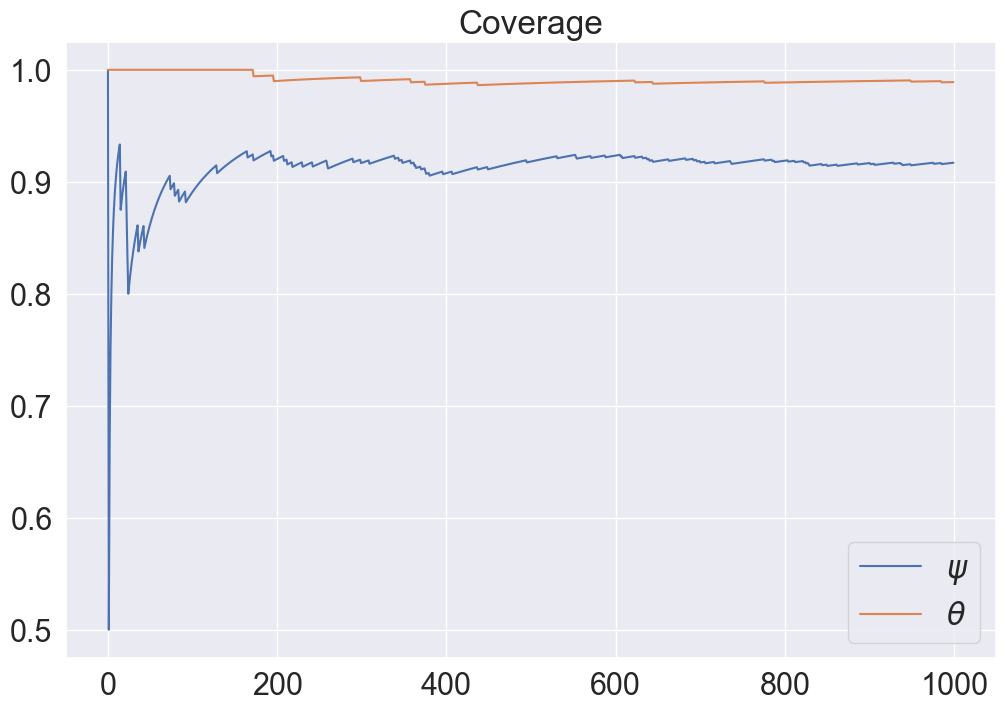

In [19]:
plt.figure(figsize=(12, 8))
plt.title("Coverage")
plt.plot(np.cumsum(coverage_psi) / np.cumsum(np.ones_like(coverage_psi)), label=r"$\psi$")
plt.plot(np.cumsum(coverage_theta) / np.cumsum(np.ones_like(coverage_theta)), label=r"$\theta$")
plt.legend()

## 1.2 Let’s Return to the “Relative Fitness” Problem

### Step 1. Compute the Expected Fisher Information Matrix for the Gamma Distribution

In [142]:
from scipy.special import polygamma

def I_gamma(alpha, beta):
    I_matrics = [
        [-polygamma(1, alpha), 1 / beta],
        [1 / beta, -alpha / beta**2]
    ]
    return -np.array(I_matrics)

In [143]:
from scipy.stats import gamma
alpha = 0.23
beta = 5.35
X = gamma.rvs(scale=1 / beta, a=alpha, size=100)

I_matrics = len(X) * I_gamma(alpha=alpha, beta=beta)

In [144]:
variance_matrix = np.linalg.inv(I_matrics)

### Step 2. We Want One-Dimensional Intervals

In [145]:
q = st.norm.ppf(.975) # 95% интервал
std = np.sqrt(variance_matrix[0, 0])

In [146]:
alpha - std * q, alpha + std * q

(np.float64(0.18066085714249608), np.float64(0.27933914285750394))

### Step 3. We Want a Two-Dimensional Interval

To construct a 95% confidence region in two dimensions, we need a bit of geometry: specifically, how to draw an ellipse that contains 95% of the probability mass. The derivations are not complicated, so I suggest reading them here:

https://www.visiondummy.com/2014/04/draw-error-ellipse-representing-covariance-matrix/

In [19]:
eigen_vals, eigen_vectors = np.linalg.eig(variance_matrix)

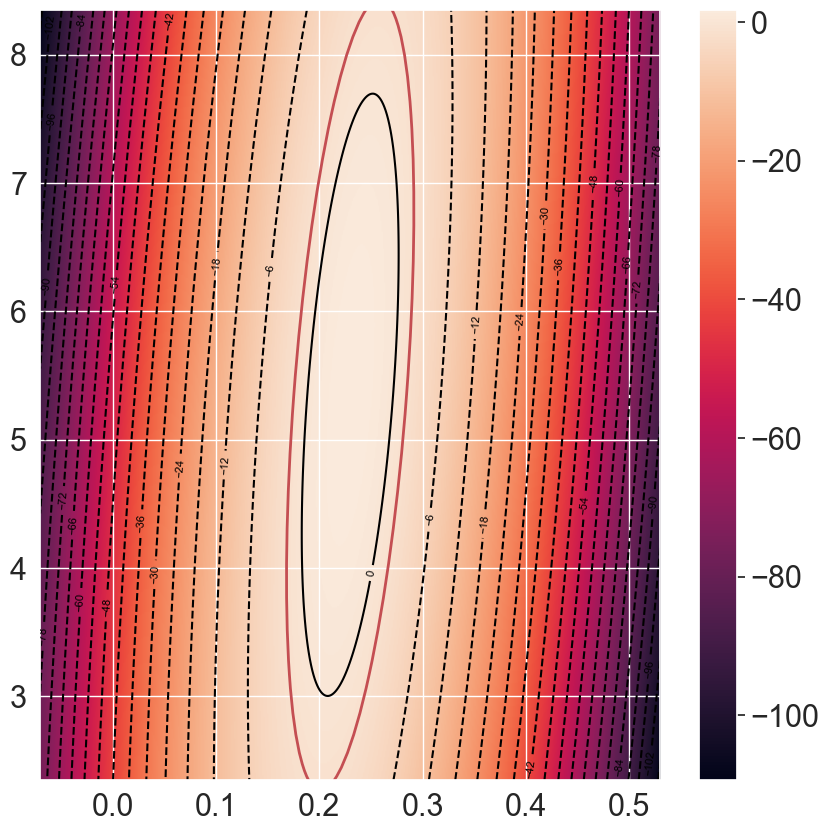

In [20]:
from scipy.stats import multivariate_normal
from matplotlib.patches import Ellipse

N = 500
x = np.linspace(alpha - 0.3, alpha + 0.3, N)
y = np.linspace(beta - 3., beta + 3., N)
X,Y = np.meshgrid(x, y)
pos = np.array([X.flatten(), Y.flatten()]).T
rv = multivariate_normal([alpha, beta], variance_matrix)
logpdf = rv.logpdf(pos).reshape(N, N)

fig = plt.figure(figsize=(10, 10))
contours = plt.contour(X, 
                       Y, 
                       logpdf, 
                       20, 
                       colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(logpdf, extent=[alpha - 0.3, alpha + 0.3, beta - 3., beta + 3.], 
           aspect='auto', origin='lower', alpha=1.)
plt.colorbar();

ax = plt.gca()
angle = np.arctan2(eigen_vectors[0][1], eigen_vectors[0][0])
ellipse = Ellipse(xy=(alpha, beta), 
                  width=2 * np.sqrt(5.991 * eigen_vals[0]), 
                  height=2 * np.sqrt(5.991 * eigen_vals[1]), 
                  angle=-angle * 180 / np.pi,
                  edgecolor='r', fc='None', lw=2)
ax.add_patch(ellipse)

plt.show()

## (Homework) Naturalization of Wald Intervals

As you have noticed, changing the parameterization strongly affects the behavior of Wald intervals.  
To find an optimal parameterization, one can use the delta method to construct a transformation $g(\theta)$ for which the variance becomes constant.

To do this, we need to solve the differential equation:

$$
\sigma(g(\theta)) = \frac{1}{\sqrt{I(\theta)}}\, g'(\theta) = \mathrm{const}
$$

which implies

$$
g'(\theta) \sim \sqrt{I(\theta)}.
$$

In the homework, you will try to construct such a transformation and compare the coverage of Wald intervals for the Gamma distribution under the standard parameterization and under the parameterization you derive.

## 1.2 (Extra) Delta Method for Constructing a Confidence Interval for the Correlation

## Definition of the Delta Method


Let $X$ be normally distributed and suppose  
$\sqrt{n}(\bar{X}_n - \mu) \rightarrow \mathcal{N}(0, \sigma^2)$.  
Then:

$$
\sqrt{n}\,\big(g(\bar{X}_n) - g(\mu)\big)
\;\rightarrow\;
\mathcal{N}\!\left(0,\, \sigma^2\, g'(\mu)^2\right)
$$

Efron (1982) analyzed the results of two exams: LSAT (law school admission test) and GPA (grade point average).  
For 15 law schools he collected the average LSAT and GPA scores.

1. Compute the empirical correlation between LSAT and GPA.

2. If $(X, Y)$ is bivariate normal with correlation coefficient $\rho$, and $r$ is the sample Pearson correlation, then using the delta method we can show that

$$
\sqrt{n}\,(r - \rho) \;\xrightarrow{d}\; \mathcal{N}\bigl(0,\,(1 - \rho^2)^2\bigr).
$$

Let us prove this.

First recall the sample estimators of variances and covariance:

$$
s_{xx} = \frac{1}{n - 1}\sum_{i=1}^n (x_i - \bar{x})^2,
\qquad
s_{yy} = \frac{1}{n - 1}\sum_{i=1}^n (y_i - \bar{y})^2,
$$

$$
s_{xy} = \frac{1}{n - 1}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}).
$$

For the delta method we need the asymptotic covariance matrix of these estimators.  
For a bivariate normal distribution, a classical result gives:

$$
\mathrm{Var}\!\left(\sqrt{n - 1}
\begin{bmatrix}
s_{xx} \\
s_{yy} \\
s_{xy}
\end{bmatrix}
\right)
=
\begin{bmatrix}
2\sigma_{xx}^2 & 2\sigma_{xy}^2 & 2\sigma_{xx}\sigma_{xy} \\
2\sigma_{xy}^2 & 2\sigma_{yy}^2 & 2\sigma_{yy}\sigma_{xy} \\
2\sigma_{xx}\sigma_{xy} & 2\sigma_{yy}\sigma_{xy} & \sigma_{xy}^2 + \sigma_{xx}\sigma_{yy}
\end{bmatrix},
$$

where  
$\sigma_{xx} = \mathrm{Var}(X)$,  
$\sigma_{yy} = \mathrm{Var}(Y)$,  
$\sigma_{xy} = \mathrm{Cov}(X,Y)$.

The sample Pearson correlation is

$$
r = \frac{s_{xy}}{\sqrt{s_{xx}s_{yy}}}.
$$
Consider the population version:

$$
r = g(\sigma_{xx}, \sigma_{yy}, \sigma_{xy})
= \frac{\sigma_{xy}}{\sqrt{\sigma_{xx}\sigma_{yy}}}.
$$

We compute the gradient of this function.  
Correct partial derivatives:

$$
\frac{\partial r}{\partial \sigma_{xy}}
= \frac{1}{\sqrt{\sigma_{xx}\sigma_{yy}}},
$$

$$
\frac{\partial r}{\partial \sigma_{xx}}
= -\frac{1}{2}\frac{\sigma_{xy}}{\sigma_{xx}^{3/2}\sigma_{yy}^{1/2}}
= -\frac{r}{2\sigma_{xx}},
$$

$$
\frac{\partial r}{\partial \sigma_{yy}}
= -\frac{1}{2}\frac{\sigma_{xy}}{\sigma_{xx}^{1/2}\sigma_{yy}^{3/2}}
= -\frac{r}{2\sigma_{yy}}.
$$
Let

$$
\nabla g =
\begin{bmatrix}
\frac{\partial r}{\partial \sigma_{xx}} \\
\frac{\partial r}{\partial \sigma_{yy}} \\
\frac{\partial r}{\partial \sigma_{xy}}
\end{bmatrix}.
$$

By the delta method:

$$
(n - 1)\,\mathrm{Var}(r)
\approx
\nabla g^\top
\,
\mathrm{Var}\!\left(\sqrt{n - 1}
\begin{bmatrix}
s_{xx} \\
s_{yy} \\
s_{xy}
\end{bmatrix}
\right)
\nabla g.
$$

Using the identity

$$
\sigma_{xy} = \rho\sqrt{\sigma_{xx}\sigma_{yy}},
$$

and simplifying the expression, we obtain the classical result:

$$
n\,\mathrm{Var}(r) \approx (1 - \rho^2)^2.
$$

Therefore,

$$
\sqrt{n}\,(r - \rho)
\;\xrightarrow{d}\;
\mathcal{N}\bigl(0,\,(1 - \rho^2)^2\bigr).
$$

In [149]:
lsat = [
    576, 580, 653, 635, 555, 
    575, 558, 661, 545, 578, 
    651, 572, 666, 605, 594
]

gpa = [
    3.39, 3.07, 3.12, 3.30, 3.00, 
    2.74, 2.81, 3.43, 2.76, 3.03, 
    3.36, 2.88, 3.44, 3.13, 2.96
]

#### 1. Calculate the correlation of LSAT and GPA

In [150]:
from scipy.stats import pearsonr
pearsonr(lsat, gpa)

PearsonRResult(statistic=np.float64(0.7763744912894069), pvalue=np.float64(0.0006651020111028153))

In [151]:
corr, _ = pearsonr(lsat, gpa)
corr

np.float64(0.7763744912894069)

In [152]:
SE_corr = np.sqrt((1 - corr**2)**2 / (len(lsat) - 1))
print(SE_corr)

0.10616756378584874


# 2. Using Likelihood Profiling to Construct Confidence Intervals

By Wald’s theorem,

$$
I_{n}(\theta)\,(\hat\theta - \theta)^2 \;\xrightarrow{d}\; \chi^2_1.
$$

By Wilks’ theorem,

$$
2\bigl[\log L(\hat\theta) - \log L(\theta)\bigr] \;\xrightarrow{d}\; \chi^2_1.
$$

Thus, likelihood profiling is conceptually very close to Wald intervals:  
both rely on the local quadratic approximation of the log‑likelihood around the MLE.

## 2.1 Estimating Confidence Intervals for the Parameters of the Gamma Distribution

Let us recall the previous example about estimating the fitness of different individuals of the same genotype:

$$
\hat{\alpha} = 0.23, \qquad \hat{\beta} = 5.35
$$

Now we will sample a training dataset from the Gamma distribution with these parameter estimates.

In [23]:
from scipy.stats import gamma
alpha_true = 0.23
beta_true = 5.35
X = gamma.rvs(scale=1 / beta_true, a=alpha_true, size=100)

#### Fit the model on the entire sample

In [24]:
fit_alpha, _, fit_beta = gamma.fit(X, floc=0)
fit_beta = 1 / fit_beta

log_likelihood_max = gamma.logpdf(X, loc=0, a=fit_alpha, scale=1 / fit_beta).sum()
print(fit_alpha, 1 / fit_beta, log_likelihood_max)

0.2594753573998625 0.1352631168671401 350.6345937156941


### Profiling the Likelihood with Respect to $\alpha$

Let us now look more carefully at the idea of likelihood profiling.

0. First, find the global maximum of the likelihood:
   $$
   \mathcal{L}_{\max} = \max_{\alpha,\,\beta} \mathcal{L}(\alpha, \beta).
   $$

1. Choose an interval for the parameter of interest:
   $$
   \alpha \in [\alpha_1,\, \alpha_2].
   $$

2. For each fixed value of $\alpha$ in this interval, maximize the likelihood with respect to $\beta$:
   $$
   \mathcal{L}_\alpha = \max_{\beta} \mathcal{L}(\alpha, \beta).
   $$

3. Plot the profile likelihood curve $(\alpha,\, \mathcal{L}_\alpha)$ and determine the confidence interval by applying the cutoff
   $$
   \mathcal{L}_\alpha - \mathcal{L}_{\max} > -\mathrm{cut\_level}_{0.95},
   $$
   where
   $$
   \mathrm{cut\_level}_{0.95} = \chi^2_{0.95}(1) / 2.
   $$

In [25]:
from scipy.stats import chi2
q = 0.90
cut_level = chi2.ppf(q=q, df=1) / 2

In [26]:
fit_alphas = []
fit_betas = []
log_likelihoods = []
alphas = np.linspace(0.1, 0.5, 100)
for alpha in alphas:
    fit_alpha, _, fit_beta = gamma.fit(X, floc=0, fa=alpha)
    fit_betas.append(1 / fit_beta)
    fit_alphas.append(fit_alpha)
    log_likelihoods.append(gamma.logpdf(X, loc=0, a=alpha, scale=fit_beta).sum())

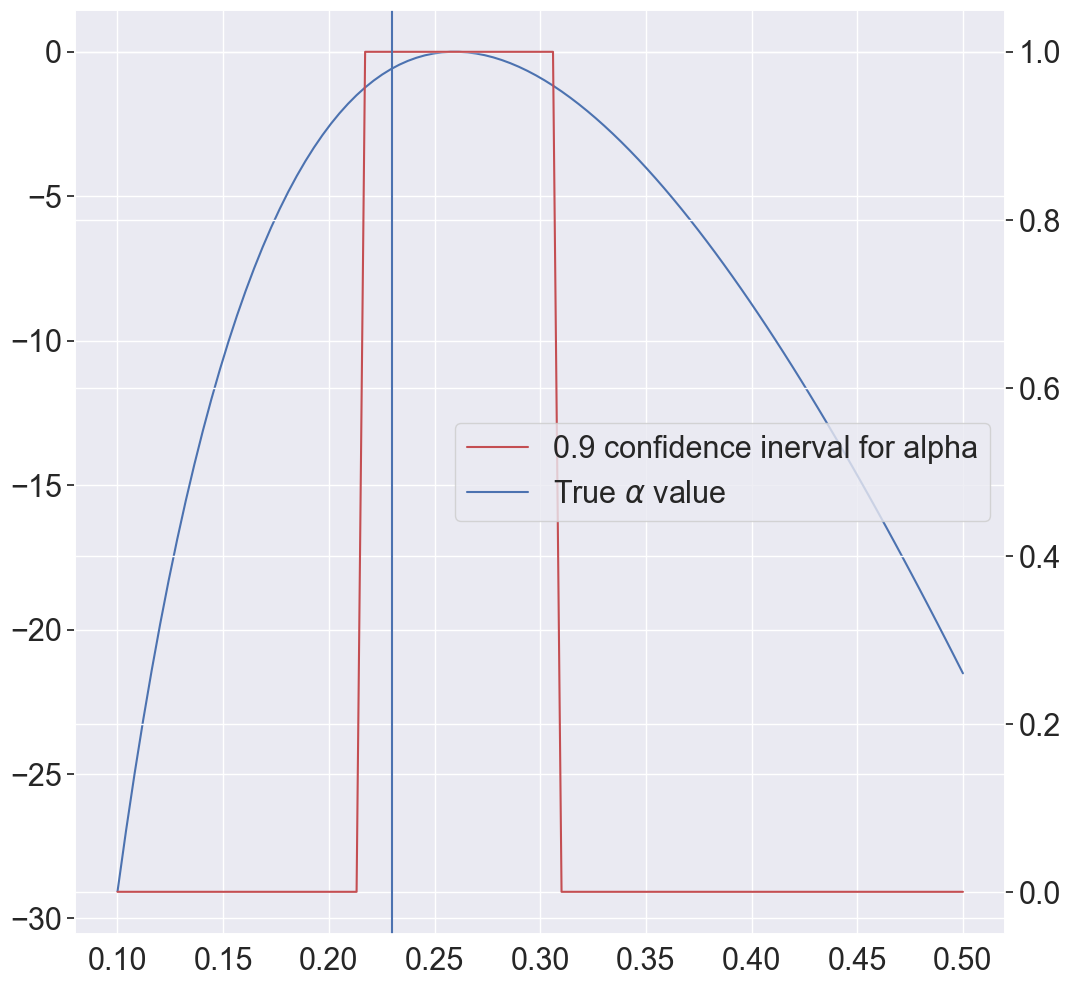

In [27]:
plt.figure(figsize=(12, 12))
plt.plot(alphas, 
         (np.array((log_likelihoods)) - log_likelihood_max), 
         label='Likelihood value')
plt.twinx()
plt.plot(alphas, 
         (np.array((log_likelihoods)) - log_likelihood_max > -cut_level), 
         c='r', label='{} confidence inerval for alpha'.format(q))
plt.axvline(alpha_true, label=r'True $\alpha$ value')
plt.legend()
plt.show()

### Profiling the Likelihood with Respect to $\beta$
we do the same thing

In [28]:
fit_alphas = []
fit_betas = []
log_likelihoods = []
betas = np.linspace(0.001, 10, 100)
for beta in betas:
    fit_alpha, _, fit_beta = gamma.fit(X, floc=0, fscale=1 / beta)
    fit_betas.append(1 / fit_beta)
    fit_alphas.append(fit_alpha)
    log_likelihoods.append(gamma.logpdf(X, loc=0, a=fit_alpha, scale=fit_beta).sum())

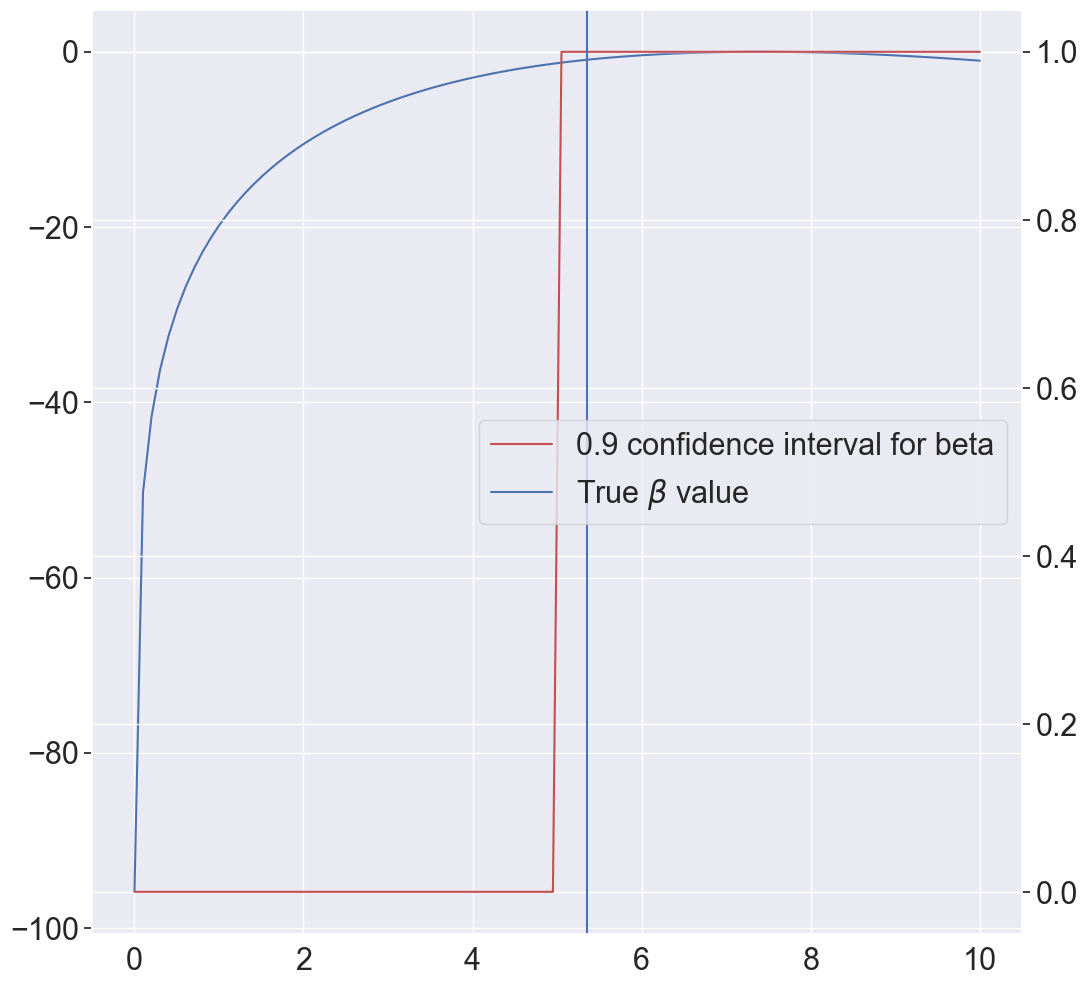

In [29]:
plt.figure(figsize=(12, 12))
plt.plot(betas, 
         (np.array((log_likelihoods)) - log_likelihood_max), 
         label='Likelihood value')
plt.twinx()
plt.plot(betas, 
         (np.array((log_likelihoods)) - log_likelihood_max > -cut_level), 
         c='r', label='{} confidence interval for beta'.format(q))
plt.axvline(beta_true, label=r'True $\beta$ value')
plt.legend()
plt.show()

### 2.2 Two‑Dimensional Likelihood Profiling


In [30]:
alphas, betas = np.meshgrid(alphas, betas)

In [31]:
alphas.shape

(100, 100)

In [32]:
log_likelihoods = []
for alpha, beta in zip(alphas.ravel(), betas.ravel()):
    log_likelihoods.append(gamma.logpdf(X, loc=0, a=alpha, scale=1 / beta).sum() - log_likelihood_max)

In [33]:
cut_level = chi2.ppf(q=q, df=2) / 2

In [34]:
log_likelihoods = np.array(log_likelihoods).reshape(alphas.shape)

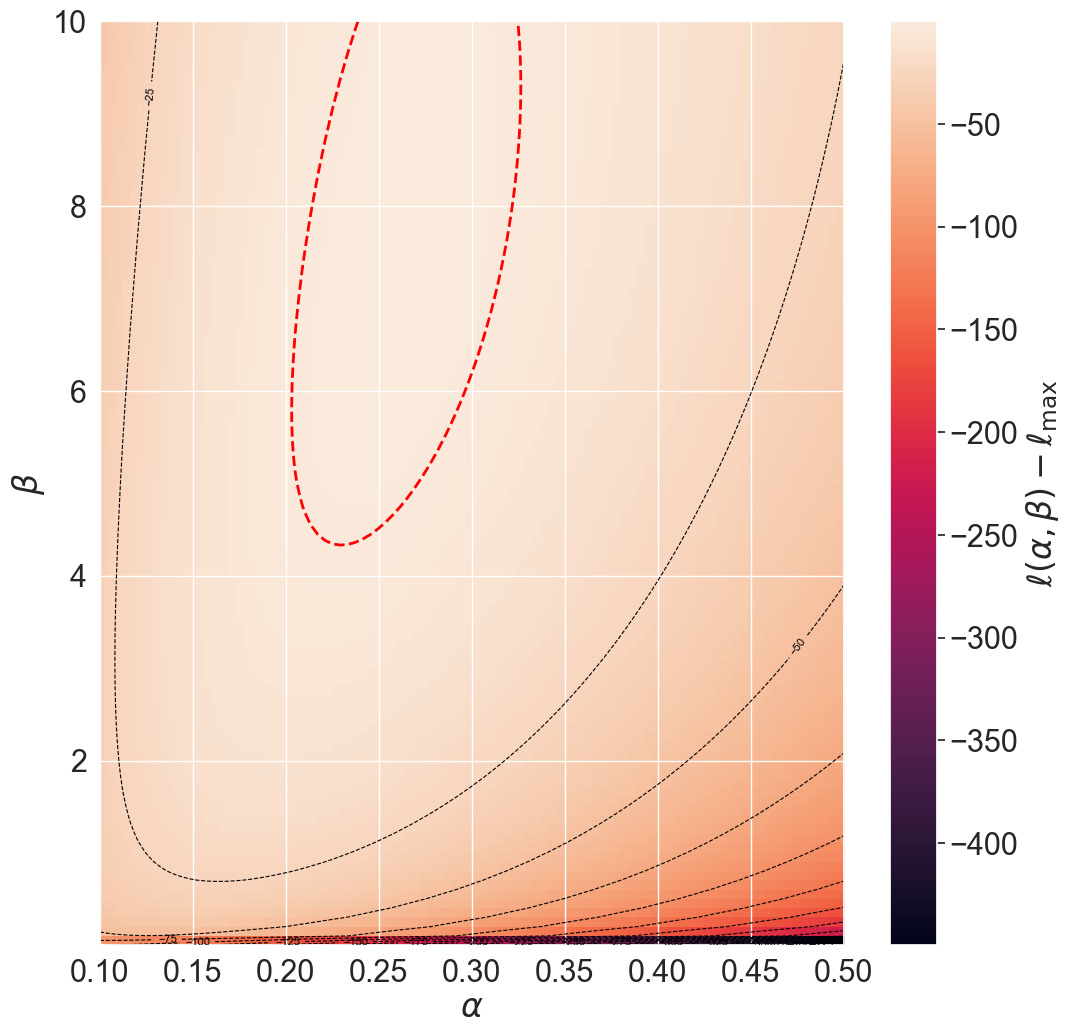

In [ ]:
alpha_vals = np.linspace(0.1, 0.5, 100)
beta_vals  = np.linspace(0.001, 10, 100)
A, B = np.meshgrid(alpha_vals, beta_vals, indexing="xy")

Z = np.array([
    gamma.logpdf(X, loc=0, a=a, scale=1/b).sum() - log_likelihood_max
    for a, b in zip(A.ravel(), B.ravel())
]).reshape(A.shape)

cut = chi2.ppf(q=q, df=2) / 2   # df=2 for (alpha,beta)

plt.figure(figsize=(12, 12))

plt.imshow(
    Z,
    extent=[alpha_vals.min(), alpha_vals.max(), beta_vals.min(), beta_vals.max()],
    origin="lower",
    aspect="auto",
    alpha=1.0
)
plt.colorbar(label=r"$\ell(\alpha,\beta)-\ell_{\max}$")

# black contour lines
contours = plt.contour(A, B, Z, 20, colors="black", linewidths=0.8)
plt.clabel(contours, inline=True, fontsize=8)

# red boundary of the q-level LR region (analog of the ellipse)
plt.contour(A, B, Z, levels=[-cut], colors="red", linewidths=2)

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\beta$")
plt.show()


## 2.2 Estimating Coverage for a Bernoulli Variable

In [159]:
true_p = 0.1

q = st.norm.ppf((1 + 0.68)/2) # 68% интервал
log_likelihood = lambda x, n, theta, theta_hat: x * np.log(theta) + (n - x) * np.log(1 - theta)
cut_level = chi2.ppf(q=0.68, df=1) / 2

In [160]:
q, cut_level

(np.float64(0.9944578832097535), np.float64(0.4944732407390115))

In [ ]:
coverage_likelihood = []
coverage_psi = []
coverage_theta = []

for i in range(1000):
    x = np.random.binomial(n=1, p=true_p, size=10)
    p = np.clip(x.mean(), 1e-5, 1 - 1e-5)
    p_psi = psi(p)
    
    std_theta = 1 / np.sqrt(I_theta(x.sum(), len(x), p))
    std_psi = 1 / np.sqrt(I_psi(x.sum(), len(x), p))
    
    if p - q * std_theta < true_p < p + q * std_theta:
        coverage_theta.append(1)
    else:
        coverage_theta.append(0)
    
    if psi_inverse(p_psi - q * std_psi) < true_p < psi_inverse(p_psi + q * std_psi):
        coverage_psi.append(1)
    else:
        coverage_psi.append(0)
    

    if log_likelihood(x.sum(), len(x), true_p, p) - log_likelihood(x.sum(), len(x), p, p) > -cut_level:
        coverage_likelihood.append(1)
    else:
        coverage_likelihood.append(0)

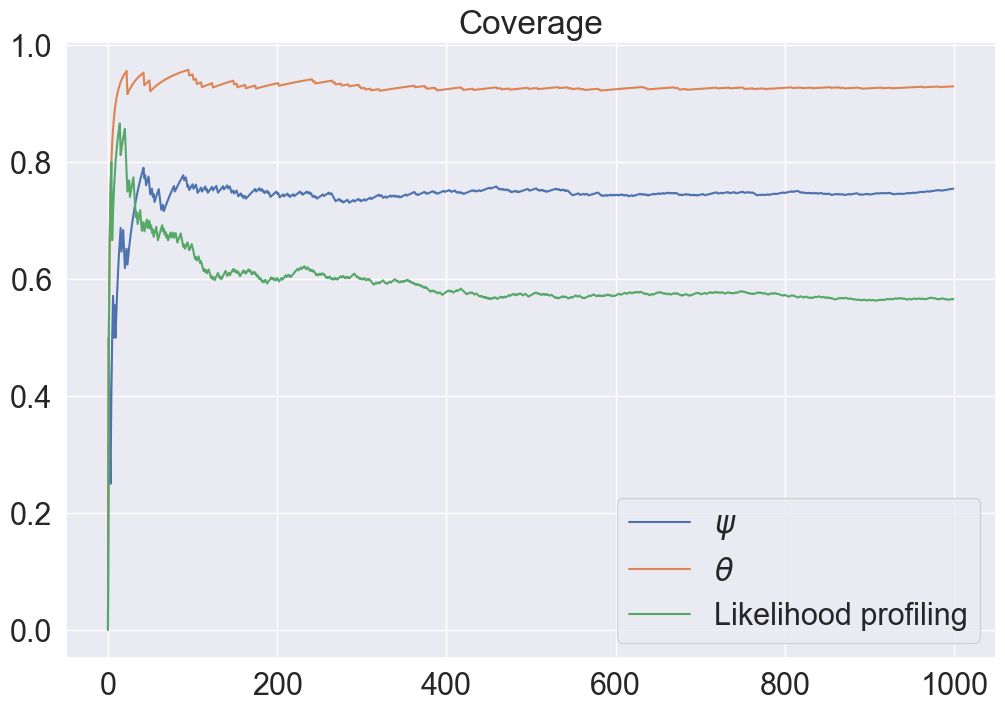

In [162]:
plt.figure(figsize=(12, 8))
plt.title("Coverage")
plt.plot(np.cumsum(coverage_psi) / np.cumsum(np.ones_like(coverage_psi)), label=r"$\psi$")
plt.plot(np.cumsum(coverage_theta) / np.cumsum(np.ones_like(coverage_theta)), label=r"$\theta$")
plt.plot(np.cumsum(coverage_likelihood) / np.cumsum(np.ones_like(coverage_likelihood)), label=r"Likelihood profiling")
plt.legend()

# 3. Using Fisher Information to Estimate Confidence Intervals and Measurement Importance

Fisher information can be used to compute parameter‑estimation errors as well as the correlations between these errors.

This follows from the [Cramér–Rao inequality](https://en.wikipedia.org/wiki/Cram%C3%A9r%E2%80%93Rao_bound), which states that the variance of any unbiased estimator is bounded below by the corresponding diagonal element of the inverse Fisher information matrix:

$$
\mathrm{Var}(\hat\theta) \;\ge\; \frac{1}{I(\theta)}.
$$

Let us now examine how Fisher information can be used to estimate the variance of parameters for a certain periodic signal.

## 3.1 Curve Fitting

### Problem Setup

#### Signal Model

Suppose we observe a periodic signal of the form

$$
a(t) = A \sin(2\pi f t + \phi),
$$

which becomes corrupted by noise during transmission.  
Assume that the noise distribution is known and Gaussian:

$$
\mathcal{N}(0, \sigma^2).
$$

Thus, at each measurement time \(t_i\) we observe

$$
\hat{a}_i \sim A \sin(2\pi f t_i + \phi) + \mathcal{N}(0, \sigma^2)
      = \mathcal{N}\!\left(A \sin(2\pi f t_i + \phi),\, \sigma^2\right).
$$

#### Goal

Given the set of measurement times $\{t_i\}_{i=1}^N $ and the corresponding noisy observations  $\{\hat{a}_i\}_{i=1}^N $ (in fact, the observations themselves will not be needed), we want to:

- estimate the uncertainties (variances) of the recovered parameters $A, f, \phi$;
- quantify the **importance** of each measurement $t_i$ for estimating each parameter.

In [23]:
# from scipy.misc import derivative
from scipy.optimize import curve_fit
import inspect
import matplotlib.pyplot as plt
import numpy as np

As a signal, we will take a sine with the following parameters: amplitude, frequency and phase.

Text(0.5, 0, 'time (s)')

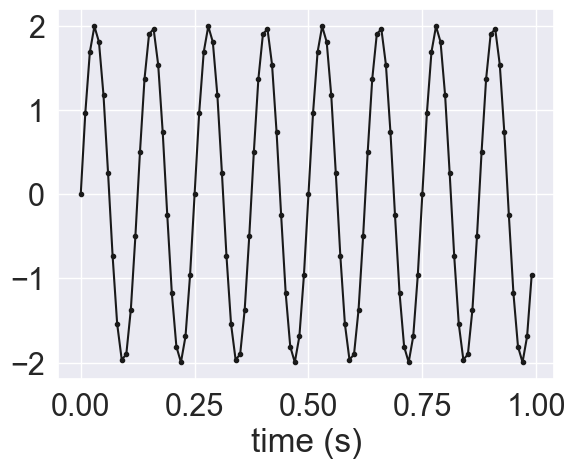

In [24]:
def signal(t, a, f, ph):
    return a * np.sin(2 * np.pi * f * t + ph)

parameters = {
    'a': 2,
    'f': 8,
    'ph': 0
}
noise = 0.1

T = np.arange(0, 1, 0.01)
plt.plot(T, signal(T, **parameters), '.-k')
plt.xlabel('time (s)')

### Derivation of the Fisher Information Matrix

Let us introduce the formal notation.

**Parameter vector:**

$$
\theta = [A, f, \phi].
$$

**Probabilistic model:**

Each measurement is corrupted by Gaussian noise with known variance:
$$
\hat{a}_i(\theta) \sim \mathcal{N}\!\left(A \sin(2\pi f t_i + \phi),\, \sigma^2\right).
$$

The log‑likelihood of a single observation is
$$
\log p(\hat{a}_i)
=
-\frac{1}{2\sigma^2}\left(\hat{a}_i - A\sin(2\pi f t_i + \phi)\right)^2
- \log(2\pi)
- \frac{1}{2}\log\sigma^2.
$$

---

### Fisher Information for a Single Measurement

The Fisher information matrix is defined as
$$
\mathcal{I}(\theta)
=
\mathbb{E}\!\left[
\left(\frac{\partial \log p(\hat{a}_i)}{\partial \theta}\right)
\left(\frac{\partial \log p(\hat{a}_i)}{\partial \theta}\right)^T
\right]
=
-\mathbb{E}\!\left[
\frac{\partial^2 \log p(\hat{a}_i)}{\partial \theta^2}
\right].
$$

Let
$$
a(t_i) = A\sin(2\pi f t_i + \phi).
$$

The gradient of the log‑likelihood is
$$
\frac{\partial \log p(\hat{a}_i)}{\partial \theta_m}
=
-\frac{1}{\sigma^2}\, a'_{\theta_m}(t_i)\,\bigl(a(t_i) - \hat{a}_i\bigr).
$$

The Hessian is
$$
\frac{\partial^2 \log p(\hat{a}_i)}{\partial \theta_m \partial \theta_n}
=
-\frac{1}{\sigma^2} a''_{\theta_m,\theta_n}(t_i)\,\bigl(a(t_i) - \hat{a}_i\bigr)
-\frac{1}{\sigma^2} a'_{\theta_m}(t_i)\, a'_{\theta_n}(t_i).
$$

Since  
$\mathbb{E}[\hat{a}_i] = a(t_i)$,  
the expectation eliminates the first term:

$$
\mathbb{E}\!\left[
\frac{\partial^2 \log p(\hat{a}_i)}{\partial \theta_m \partial \theta_n}
\right]
=
-\frac{1}{\sigma^2} a'_{\theta_m}(t_i)\, a'_{\theta_n}(t_i).
$$

---

### Final Expression for the Fisher Information

Summing over all measurements:

$$
\mathcal{I}(\theta)
=
\frac{1}{\sigma^2}
\sum_{i=1}^N
\left(
\frac{\partial a(t_i)}{\partial \theta}
\right)
\left(
\frac{\partial a(t_i)}{\partial \theta}
\right)^T.
$$

In component form:

$$
\mathcal{I}_{mn}
=
\frac{1}{\sigma^2}
\sum_{i=1}^N
\frac{\partial a(t_i)}{\partial \theta_m}
\frac{\partial a(t_i)}{\partial \theta_n}.
$$

Define the sensitivity matrix

$$
D_{mi} := \frac{\partial a(t_i)}{\partial \theta_m},
$$

then the Fisher information becomes

$$
\mathcal{I}_{mn}
=
\frac{1}{\sigma^2}
\sum_{i=1}^N
D_{mi} D_{ni}.
$$

In [25]:
{**parameters, **{'a': 5}}

{'a': 5, 'f': 8, 'ph': 0}

In [26]:
A = parameters["a"]
f = parameters["f"]
phi = parameters["ph"]

D = np.zeros((3, len(T)))

for k, t in enumerate(T):
    D[0, k] = np.sin(2*np.pi*f*t + phi)                 # d/dA
    D[1, k] = A * 2*np.pi*t * np.cos(2*np.pi*f*t + phi) # d/df
    D[2, k] = A * np.cos(2*np.pi*f*t + phi)             # d/dphi

Let us examine how $D$ behaves for different variables.
Note again that the number of rows in the matrix $D$ matches the length of the parameter vector $\theta$ , and the number of columns matches the number of measurements.

In [27]:
D.shape

(3, 100)

Text(0.5, 0, 'time (s)')

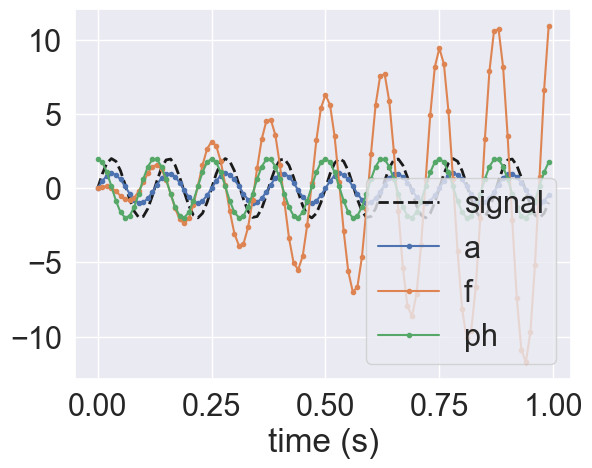

In [168]:
plt.plot(T, signal(T, **parameters), '--k', lw=2, label='signal')

for Di, argname in zip(D, parameters.keys()):
    plt.plot(T, Di, '.-', label=argname)
    
plt.legend(loc='best')
plt.xlabel('time (s)')

The matrix $D_{ik}$ shows how strongly the $k$-th measurement influences the $i$-th parameter.  
For example, we can see that the amplitude parameter is affected most strongly by measurements taken near the peaks of the sine wave.

In addition, the last measurement points turn out to be more sensitive to the frequency.

Now let us compute the Fisher information matrix using the sensitivity matrix \(D\):

$$
\mathcal{I}_{m,n} = \frac{1}{\sigma^2} \sum_k D_{mk} D_{nk}.
$$

This expression can be evaluated compactly using NumPy’s `einsum` function:

In [169]:
I = np.einsum('ij,kj', D, D) / noise**2
print(I)

[[ 5.00000000e+03 -5.71453582e+02  2.53130850e-12]
 [-5.71453582e+02  2.55477029e+05  6.15752160e+04]
 [ 2.53130850e-12  6.15752160e+04  2.00000000e+04]]


In the cell below, we will look at the variance of estimates for signal parameters using Kramer-Rao.

In [170]:
I_inv = np.linalg.inv(I)

for argname, variance in zip(parameters.keys(), I_inv.diagonal()):
    print('{}: {:.2g}'.format(argname, np.sqrt(variance)))

a: 0.014
f: 0.0039
ph: 0.014


And here we will use the `curve_fit` function, which makes an automatic fit for the final sample and outputs optimal parameters and errors.

As you can see, they are quite similar.

It is worth noting that it is incorrect to compare errors calculated using Kramer-Rao and `curve_fit`, since they have a rather different nature.

a: 0.013
f: 0.0038
ph: 0.013


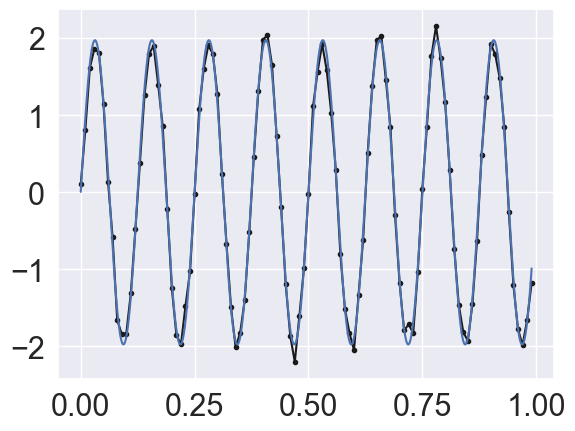

In [171]:
S = signal(T, **parameters) + np.random.randn(T.size) * noise
plt.plot(T, S, '.-k')

popt, pcov = curve_fit(signal, T, S, p0=list(parameters.values()))

for argname, variance in zip(parameters.keys(), pcov.diagonal()):
    print('{}: {:.2g}'.format(argname, np.sqrt(variance)))

Tl = np.linspace(T[0], T[-1], 10000)
plt.plot(Tl, signal(Tl, *popt))

In [67]:
def cramer_rao(model, p0, X, noise, show_plot=False):
    A = p0["a"]
    f = p0["f"]
    phi = p0["ph"]

    D = np.zeros((3, X.size))

    for k, t in enumerate(X):
        D[0, k] = np.sin(2*np.pi*f*t + phi)                 # d/dA
        D[1, k] = A * 2*np.pi*t * np.cos(2*np.pi*f*t + phi) # d/df
        D[2, k] = A * np.cos(2*np.pi*f*t + phi)             # d/dphi

    if show_plot:
        plt.plot(X, model(X, **p0), '--k', lw=2, label='signal')
        for Di, argname in zip(D, p0.keys()):
            plt.plot(X, Di, '.-', label=argname)
        plt.legend()
        plt.title('Sensitivity of parameters to measurement errors')

    I = np.einsum('mk,nk->mn', D, D) / noise**2
    return np.linalg.inv(I)

In the plot below, we show how errors at specific measurement points influence the estimates of the parameters $\theta$.

Text(0.5, 0, 'time (s)')

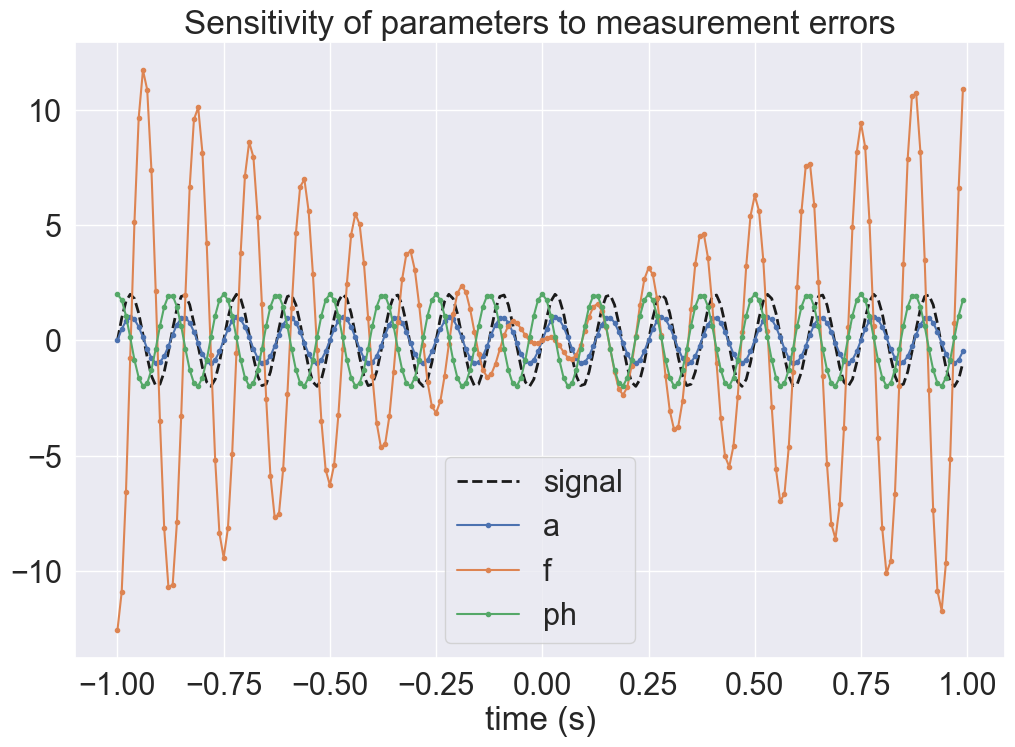

In [68]:
plt.figure(figsize=(12, 8))

T = np.arange(-1., 1, 0.01)
cramer_rao(signal, parameters, T, noise, show_plot=True);
plt.xlabel('time (s)')